## Data Analytics: Lab 09

Question 1:
When calculating the sample standard deviation (or sample variance), why do we divide by
(N−1) instead of N?

I based on the following link for the answer: https://www.statisticshowto.com/bessels-correction/

The formula is the adjustment based on the Bessel’s correction: When you select very a group of samples from a big population, there is a chance that the variance (and the standard deviation) will hardly reach the true population variance and standard deviation (those values you do not even need to find most of the time) → The calculation is bias and underestimates the variability.

→ Subtract the number of samples by 1 will deal with this bias. Recommended when the number of samples is small (100 samples among 1 million), not necessary when the number of samples is close to the population (999,000 samples among 1 million).

To put it simply:
- Each sample mean $\bar{x}$.
 is “pulled toward” the sample points.

- The deviations
($x_i$ - $\bar{x}$) are slightly smaller than deviations from the true mean.

- Dividing by n−1 instead of n corrects for this shrinkage.

Question 2:

In [18]:
import pandas as pd

# Read the dataset
df = pd.read_csv('house_prices.csv').drop(columns="Unnamed: 0")
df.columns

Index(['number_of_rooms', 'floor', 'area', 'latitude', 'longitude', 'price'], dtype='object')

Computer the covariance matrix and plot a heatmap of the covariance matrix of
selected features using Seaborn package

                 number_of_rooms          floor          area     latitude  \
number_of_rooms         1.508913       0.208151  3.568124e+01     0.001512   
floor                   0.208151      20.952666  5.001178e+01     0.009666   
area                   35.681242      50.011782  1.501558e+03     0.102835   
latitude                0.001512       0.009666  1.028347e-01     0.000912   
longitude               0.001035       0.012846  1.447628e-01    -0.000736   
price              301779.308841  177740.754080  1.149226e+07  1224.799482   

                   longitude         price  
number_of_rooms     0.001035  3.017793e+05  
floor               0.012846  1.777408e+05  
area                0.144763  1.149226e+07  
latitude           -0.000736  1.224799e+03  
longitude           0.003239  1.346177e+03  
price            1346.177308  1.705542e+11  


<Axes: >

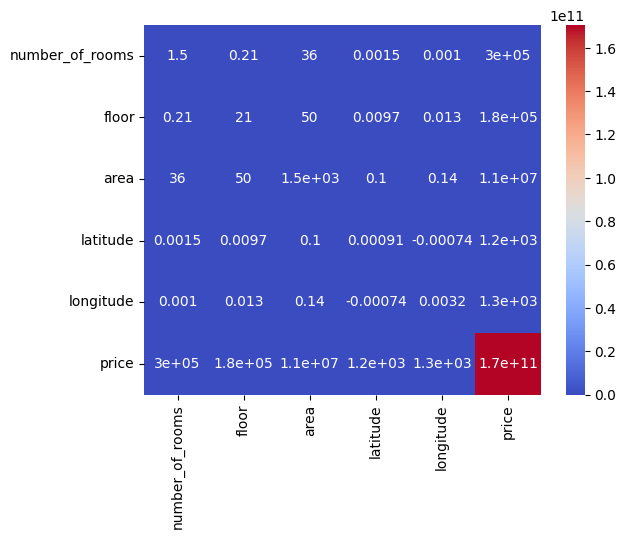

In [44]:
# Covariance Matrix
print(df.cov())
# Covariance heatmaps
import seaborn as sns
sns.heatmap(df.cov(), annot=True, cmap='coolwarm')

b) Plot the correlation heatmap of the of the correltion matrix of selected features using
Seaborn package

                 number_of_rooms     floor      area  latitude  longitude  \
number_of_rooms         1.000000  0.037019  0.749612  0.048279   0.017549   
floor                   0.037019  1.000000  0.281956  0.073479   0.051819   
area                    0.749612  0.281956  1.000000  0.102166   0.076320   
latitude                0.048279  0.073479  0.102166  1.000000  -0.428405   
longitude               0.017549  0.051819  0.076320 -0.428405   1.000000   
price                   0.594876  0.094023  0.718130  0.097400   0.056808   

                    price  
number_of_rooms  0.594876  
floor            0.094023  
area             0.718130  
latitude         0.097400  
longitude        0.056808  
price            1.000000  


<Axes: >

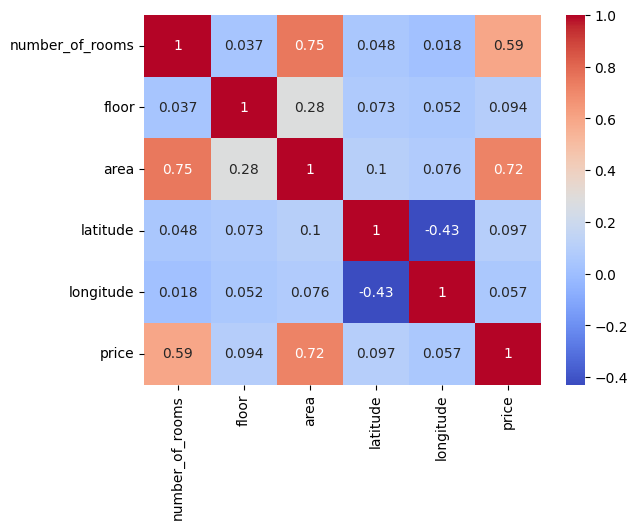

In [22]:
# Correlation Matrix
print(df.corr())
# Correlation heatmaps
import seaborn as sns
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')

Plot scatterplots of 5 highly-corelated pairs of features and 5 non corelated pairs of
d) features.

High-Correlated Pairs:
 number_of_rooms  area               0.749612
area             number_of_rooms    0.749612
price            area               0.718130
area             price              0.718130
dtype: float64


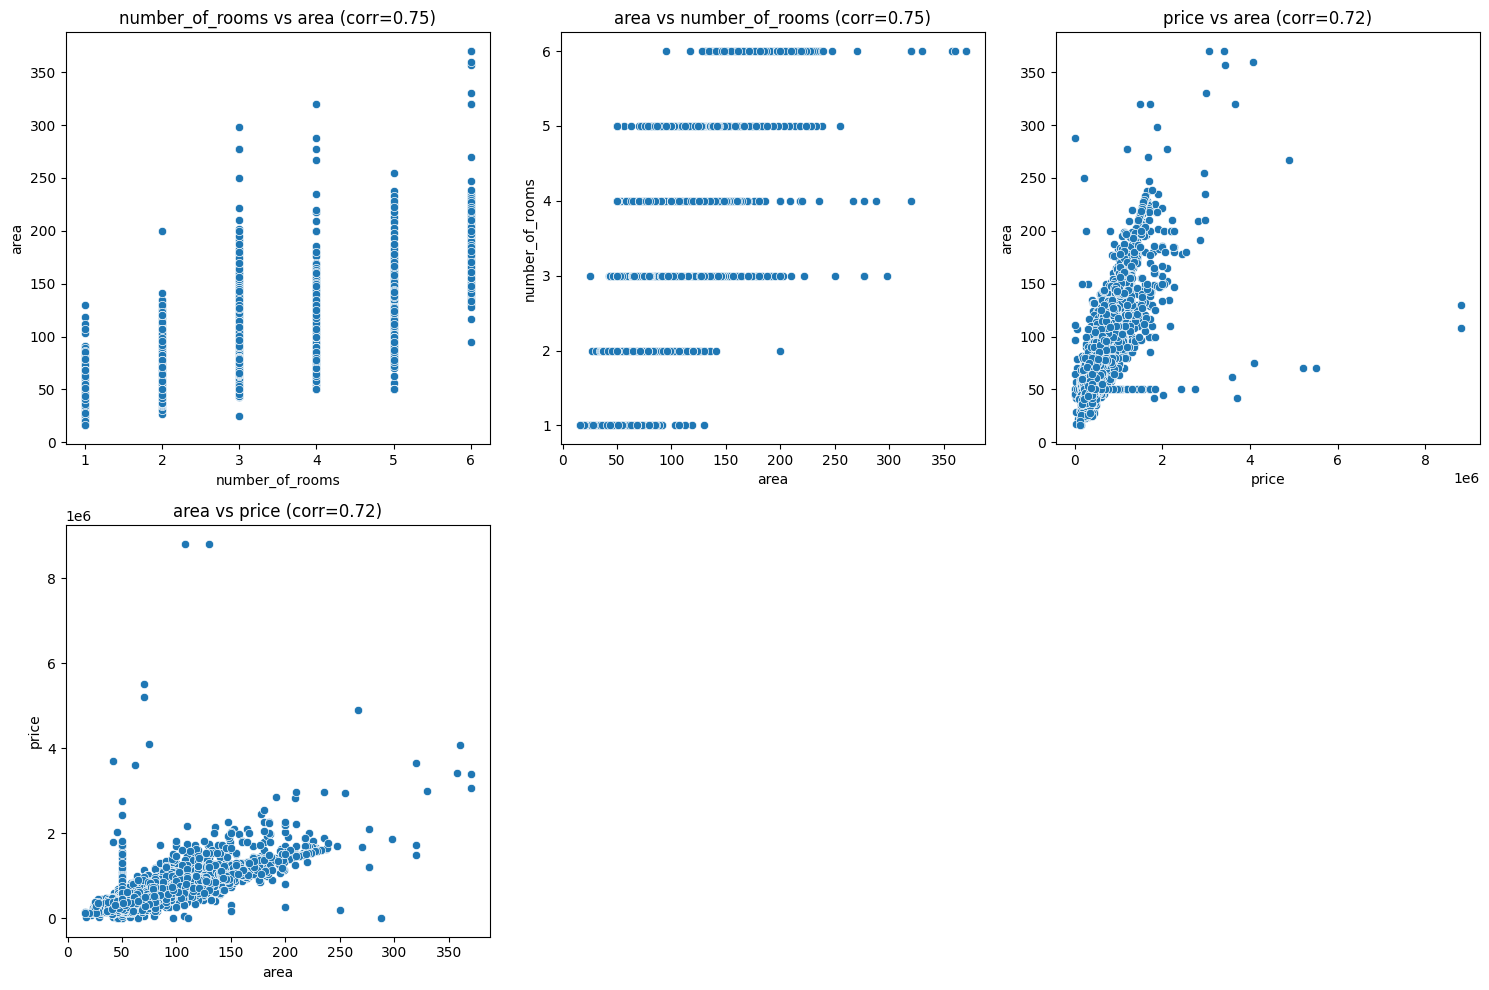

In [37]:
# Plot scatterplots of 5 highly-corelated pairs of features and 5
# non corelated pairs of features.
import seaborn as sns

# Find the 5 highly-correlated pair (> 0.7)
corr_matrix = df.corr()
corr_pairs = corr_matrix.unstack().sort_values(ascending=False)
# Remove self correlation
corr_pairs = corr_pairs[corr_pairs != 1]
# Find the 5 highly-correlated pair
high_corr_pairs = corr_pairs[corr_pairs > 0.7].head(5)
print("High-Correlated Pairs:\n", high_corr_pairs)

plt.figure(figsize=(15, 10))

for i, ((feat1, feat2), corr_val) in enumerate(high_corr_pairs.items(), 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feat1], y=df[feat2])
    plt.title(f"{feat1} vs {feat2} (corr={corr_val:.2f})")

plt.tight_layout()
plt.show()

Low correlated pairs:
 price     latitude     0.097400
latitude  price        0.097400
price     floor        0.094023
floor     price        0.094023
area      longitude    0.076320
dtype: float64


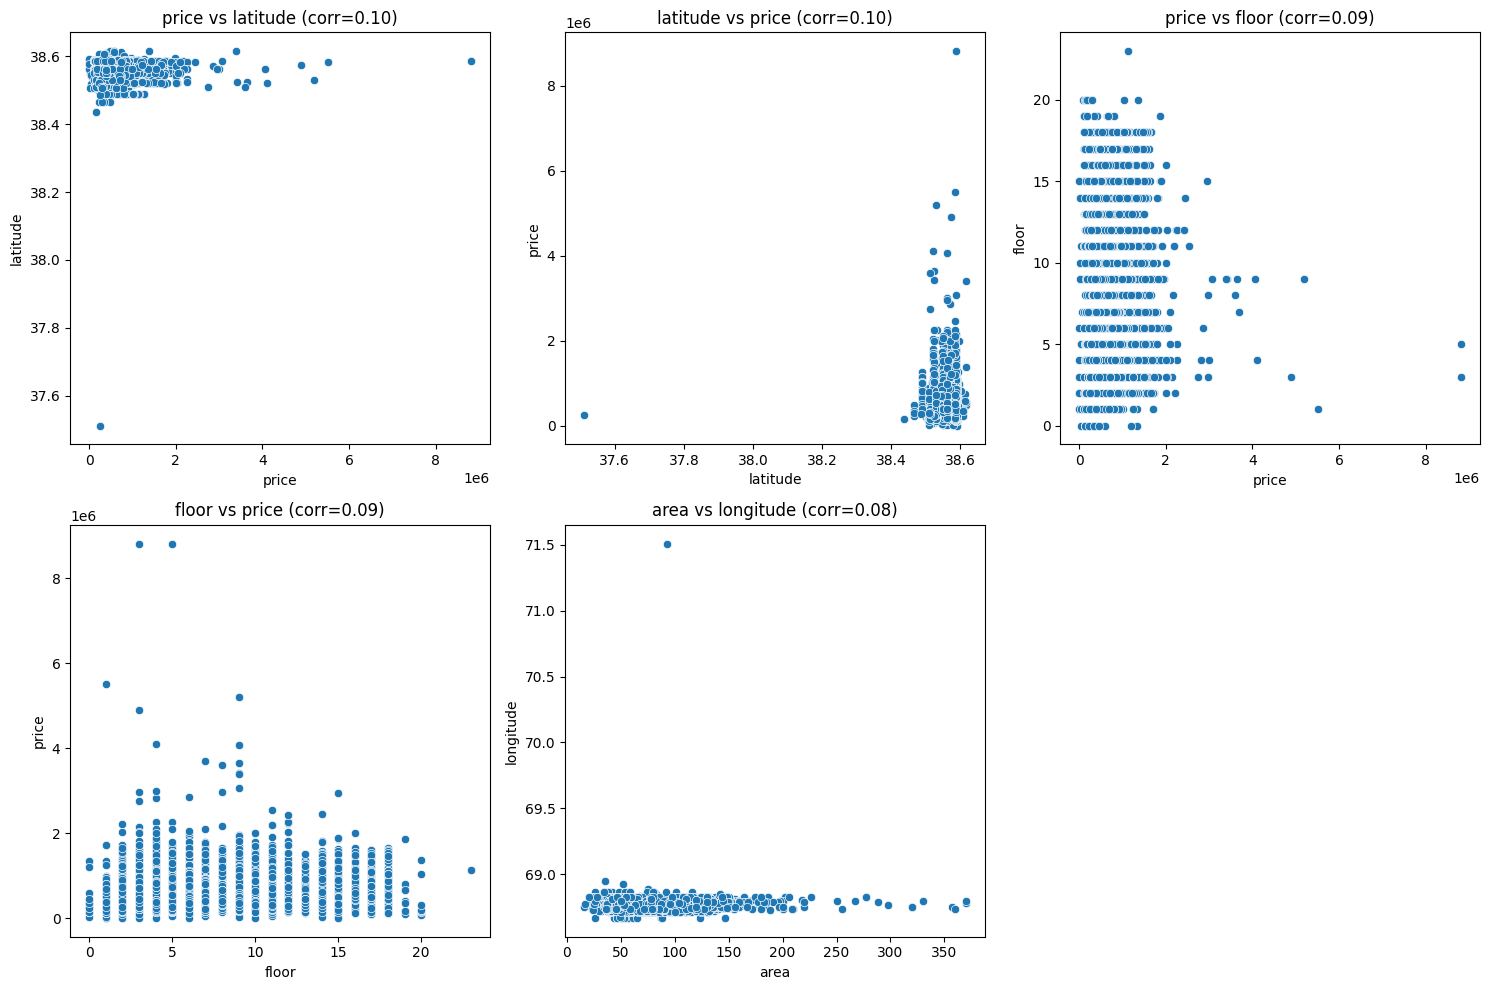

In [38]:
# 5 low-correlated pairs (|corr| < 0.1)
low_corr_pairs = corr_pairs[abs(corr_pairs) < 0.1].head(5)
print("Low-Correlated pairs:\n", low_corr_pairs)

plt.figure(figsize=(15, 10))

for i, ((feat1, feat2), corr_val) in enumerate(low_corr_pairs.items(), 1):
    plt.subplot(2, 3, i)
    sns.scatterplot(x=df[feat1], y=df[feat2])
    plt.title(f"{feat1} vs {feat2} (corr={corr_val:.2f})")

plt.tight_layout()
plt.show()

Use pandas.plotting.scatter_matrix for the selected features

array([[<Axes: xlabel='number_of_rooms', ylabel='number_of_rooms'>,
        <Axes: xlabel='floor', ylabel='number_of_rooms'>,
        <Axes: xlabel='area', ylabel='number_of_rooms'>,
        <Axes: xlabel='latitude', ylabel='number_of_rooms'>,
        <Axes: xlabel='longitude', ylabel='number_of_rooms'>,
        <Axes: xlabel='price', ylabel='number_of_rooms'>],
       [<Axes: xlabel='number_of_rooms', ylabel='floor'>,
        <Axes: xlabel='floor', ylabel='floor'>,
        <Axes: xlabel='area', ylabel='floor'>,
        <Axes: xlabel='latitude', ylabel='floor'>,
        <Axes: xlabel='longitude', ylabel='floor'>,
        <Axes: xlabel='price', ylabel='floor'>],
       [<Axes: xlabel='number_of_rooms', ylabel='area'>,
        <Axes: xlabel='floor', ylabel='area'>,
        <Axes: xlabel='area', ylabel='area'>,
        <Axes: xlabel='latitude', ylabel='area'>,
        <Axes: xlabel='longitude', ylabel='area'>,
        <Axes: xlabel='price', ylabel='area'>],
       [<Axes: xlabel='number_o

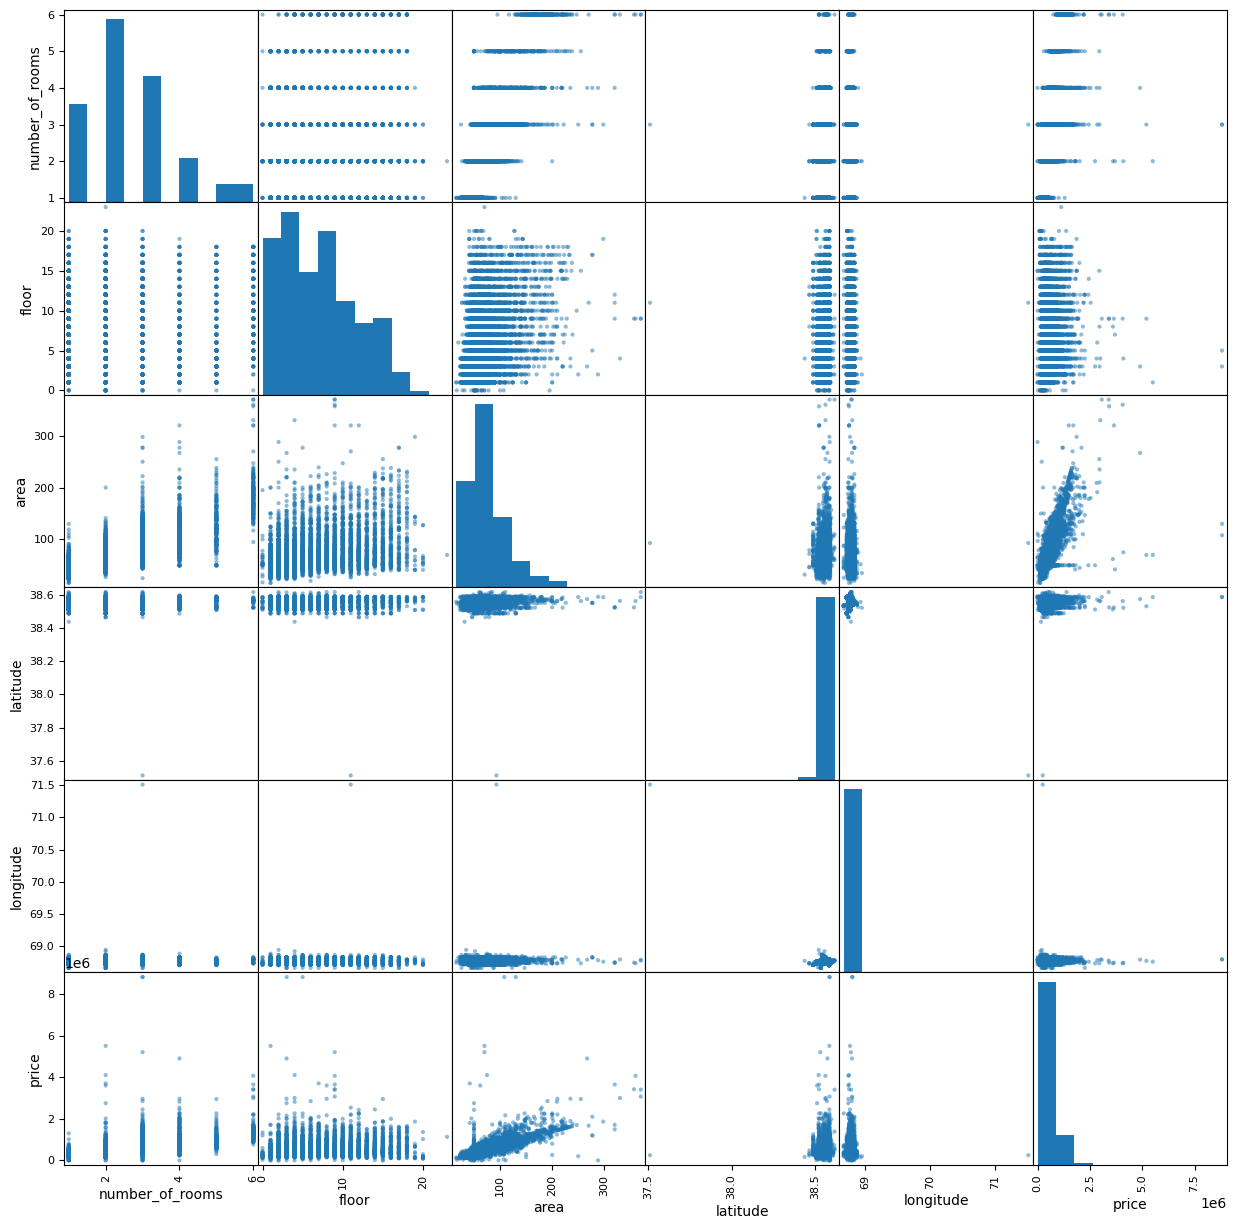

In [41]:
# Use pd.plotting.scatter_matrix
pd.plotting.scatter_matrix(frame=df, figsize=(15, 15))

Question 3:

Rank the features by importance using Random Forest Classifier.
Plot a bar chart of feature importance.

In [14]:
# Rank Features
import pandas as pd
from sklearn.preprocessing import MinMaxScaler
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score

# Read the dataset
df = pd.read_csv('diabetes.csv')

# Features and target
target = 'Outcome'
features = df.columns.drop(target)

# Split the data into 80% for training and 20% for testing
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)
X_train = train_df[features]
y_train = train_df[target]
X_test = test_df[features]
y_test = test_df[target]
# Train the model with Random Forest
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)

# Accuracy
accuracy = accuracy_score(y_test, y_pred)
print("Accuracy:", accuracy)

Accuracy: 0.7207792207792207


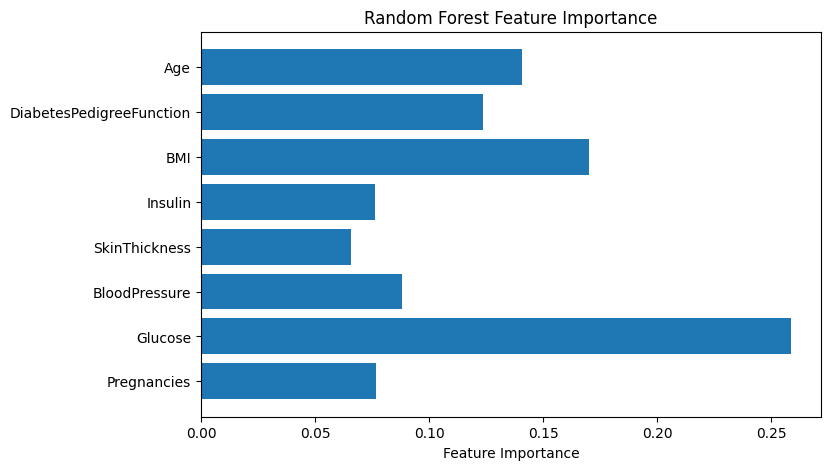

In [15]:
import matplotlib.pyplot as plt

# Feature Importance
importances = model.feature_importances_
feature_names = features

plt.figure(figsize=(8, 5))
plt.barh(feature_names, importances)
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.show()